# 💎 Predicción de Precio de Diamantes — Árbol de Decisión

En este notebook resolvemos el mismo caso de los diamantes usando un **Árbol de Decisión Regresor**.

A diferencia de OLS y KNN:
- **No asume linealidad** entre las variables y el precio
- **No requiere escalado** — los árboles son invariantes a la escala de las variables
- **Es interpretable visualmente** — podemos ver exactamente qué reglas aprendió el modelo
- **Produce importancia de variables** de forma natural


## 🌳 ¿Cómo funciona un Árbol de Decisión?

Un árbol de decisión aprende haciendo **preguntas binarias sucesivas** sobre los datos hasta llegar a una predicción.

```
¿carat > 1.05?
├── SÍ → ¿clarity == IF o VVS1?
│         ├── SÍ → precio predicho: $8,200
│         └── NO → precio predicho: $5,400
└── NO → ¿cut == Ideal?
          ├── SÍ → precio predicho: $2,100
          └── NO → precio predicho: $1,400
```

### Conceptos clave

| Término | Significado |
|---|---|
| **Nodo raíz** | Primera pregunta — la variable que mejor divide los datos |
| **Nodo interno** | Pregunta intermedia con condición de corte |
| **Hoja** | Nodo final — contiene la predicción (promedio de `price` en ese grupo) |
| **Profundidad (`max_depth`)** | Cuántos niveles de preguntas permite el árbol |
| **Impureza** | Qué tan mezclados están los valores en un nodo (se minimiza con MSE en regresión) |

### ¿Cómo elige el árbol la mejor pregunta?

En cada nodo, prueba **todos los posibles cortes** de todas las variables y elige el que reduce más el **MSE** (error cuadrático medio) de los dos grupos resultantes:

$$\text{Reducción MSE} = \text{MSE}_{padre} - \left(\frac{n_{izq}}{n} \cdot \text{MSE}_{izq} + \frac{n_{der}}{n} \cdot \text{MSE}_{der}\right)$$

### Hiperparámetro crítico: `max_depth`
- `max_depth` pequeño → árbol simple, puede **subajustar** (underfitting)
- `max_depth` grande → árbol muy detallado, puede **sobreajustar** (overfitting)


### Demostración: Overfitting vs Underfitting con `max_depth`

Antes de aplicarlo a los diamantes, veamos el efecto de `max_depth` con un ejemplo sencillo de 1 variable.


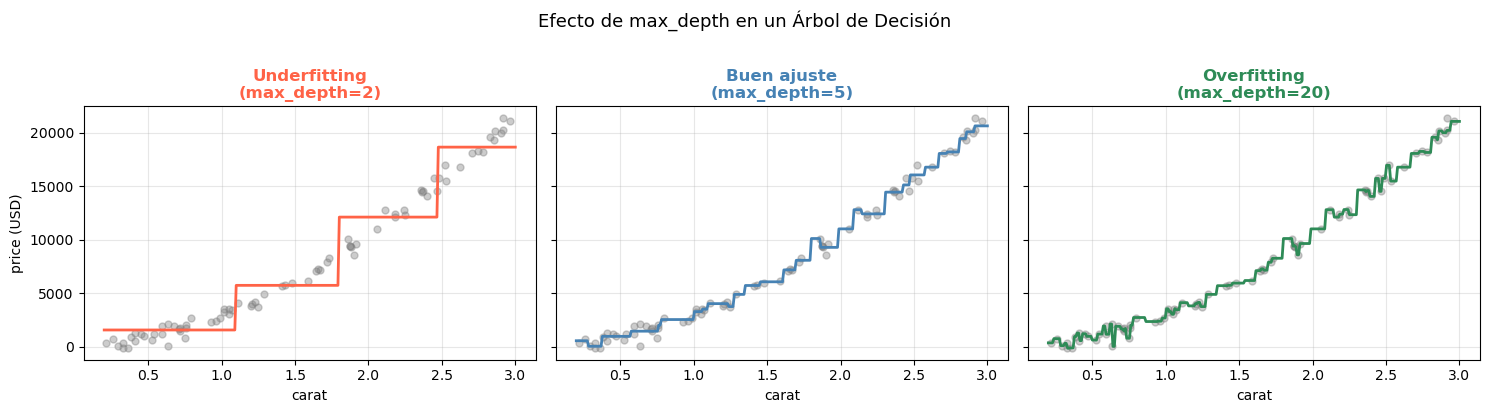

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Datos sintéticos: relación carat → price (simplificada, con ruido)
np.random.seed(42)
carat = np.sort(np.random.uniform(0.2, 3.0, 80))
price = 3000 * carat**1.8 + np.random.normal(0, 500, 80)

X_toy = carat.reshape(-1, 1)
X_plot = np.linspace(0.2, 3.0, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
configs = [
    (2,  'Underfitting\n(max_depth=2)',  'tomato'),
    (5,  'Buen ajuste\n(max_depth=5)',   'steelblue'),
    (20, 'Overfitting\n(max_depth=20)',  'seagreen'),
]

for ax, (depth, titulo, color) in zip(axes, configs):
    dt = DecisionTreeRegressor(max_depth=depth)
    dt.fit(X_toy, price)
    y_plot = dt.predict(X_plot)

    ax.scatter(carat, price, alpha=0.4, s=25, color='gray', label='Datos reales')
    ax.plot(X_plot, y_plot, color=color, lw=2, label=f'Predicción')
    ax.set_title(titulo, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('carat')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('price (USD)')
plt.suptitle('Efecto de max_depth en un Árbol de Decisión', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---

## 1️⃣ Carga de Datos

Mismo dataset de diamantes (53,940 filas) descargado desde SQLite.


In [3]:
import requests, sqlite3, pandas as pd

url = "https://raw.githubusercontent.com/davidjamesknight/SQLite_databases_for_learning_data_science/main/diamonds.db"
r = requests.get(url)

with open("diamonds.db", "wb") as f:
    f.write(r.content)

conn = sqlite3.connect("diamonds.db")

query = """
SELECT
  O.carat, O.price, O.depth, "O"."table", O.x, O.y, O.z,
  C.cut, Co.color, Cl.clarity
FROM Observation AS O
JOIN Cut     AS C  ON O.cut_id     = C.cut_id
JOIN Color   AS Co ON O.color_id   = Co.color_id
JOIN Clarity AS Cl ON O.clarity_id = Cl.clarity_id
"""

df = pd.read_sql_query(query, conn)
print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()


Dataset: 53,940 filas × 10 columnas


,carat,price,depth,table,x,y,z,cut,color,clarity
0,0.23,326,61.5,55.0,3.95,3.98,2.43,Ideal,E,SI2
1,0.21,326,59.8,61.0,3.89,3.84,2.31,Premium,E,SI1
2,0.23,327,56.9,65.0,4.05,4.07,2.31,Good,E,VS1
3,0.29,334,62.4,58.0,4.20,4.23,2.63,Premium,I,VS2
4,0.31,335,63.3,58.0,4.34,4.35,2.75,Good,J,SI2


## 2️⃣ Preprocesamiento

Los árboles de decisión **no necesitan escalado** — los cortes son comparaciones (`carat > 1.05?`), no distancias.  
Pero sí necesitamos convertir las variables categóricas ordinales a números con `OrdinalEncoder`, igual que en OLS y KNN.

> **Diferencia clave vs KNN:** aquí omitimos el `StandardScaler` completamente.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Encoding ordinal — mismo orden que en los otros notebooks
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

enc = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
cat_cols = ['cut', 'color', 'clarity']

X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

X_train_enc[cat_cols] = enc.fit_transform(X_train[cat_cols])
X_test_enc[cat_cols]  = enc.transform(X_test[cat_cols])

# Sin StandardScaler — los árboles no lo necesitan
print(f"Train: {X_train_enc.shape} | Test: {X_test_enc.shape}")
X_train_enc.head()


Train: (43152, 9) | Test: (10788, 9)


,carat,depth,table,x,y,z,cut,color,clarity
26546,2.01,58.1,64.0,8.23,8.19,4.77,1.0,4.0,1.0
9159,1.01,60.0,60.0,6.57,6.49,3.92,2.0,5.0,1.0
14131,1.10,62.5,58.0,6.59,6.54,4.10,3.0,2.0,3.0
15757,1.50,61.5,65.0,7.21,7.17,4.42,1.0,5.0,1.0
24632,1.52,62.1,57.0,7.27,7.32,4.53,2.0,3.0,4.0


## 3️⃣ Pipeline y Búsqueda de Hiperparámetros con GridSearchCV

Usamos un **Pipeline** para encadenar el modelo, y **GridSearchCV** para probar todas las combinaciones de hiperparámetros con validación cruzada.

> Los parámetros del Pipeline se referencian con `nombre_paso__nombre_parametro`.  
> Ej: `'tree__max_depth'` apunta al `max_depth` del paso llamado `'tree'`.


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('tree', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'tree__max_depth':         [3, 5, 7, 9, 11],
    'tree__min_samples_split': [2, 20, 50],
    'tree__min_samples_leaf':  [1, 10, 25],
}

grid = GridSearchCV(pipe, param_grid, cv=5,
                    scoring='neg_root_mean_squared_error',
                    n_jobs=-1, verbose=1)
grid.fit(X_train_enc, y_train)

print(f"\nMejores parámetros: {grid.best_params_}")
print(f"RMSE CV:            {-grid.best_score_:.2f} USD")


Fitting 5 folds for each of 45 candidates, totalling 225 fits


Traceback (most recent call last):
  File "/opt/anaconda3/envs/business-analytics/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzLzIxL3dibTBqbTMxMGg5YjYyZGRwbjUwbDI5YzAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl8zMDg1MV80YzNkZjA1N2Y0YTI0Yzg1ODQ2OTU5MDU0OGQzMzk1ZF8xNTU4MTk3ZGYyMTI0NjhjYmQzMTdjOGMxZTNhZDFhYQ=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/opt/anaconda3/envs/business-analytics/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktMzA4NTEtcXg3cz


Mejores parámetros: {'tree__max_depth': 11, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 20}
RMSE CV:            629.14 USD


## 4️⃣ Ajuste del Árbol Final

Entrenamos el árbol con el `max_depth` óptimo encontrado por CV.


In [6]:
dt_final  = grid.best_estimator_   # Pipeline completo (para predict)
tree      = dt_final['tree']        # Árbol interno (para plot_tree y feature_importances_)
best_depth = grid.best_params_['tree__max_depth']

print(f"Mejores parámetros: {grid.best_params_}")
print(f"Hojas: {tree.get_n_leaves()}")
print(f"Nodos: {tree.tree_.node_count}")


Mejores parámetros: {'tree__max_depth': 11, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 20}
Hojas: 1085
Nodos: 2169


## 5️⃣ Visualización del Árbol

Una de las ventajas clave de los árboles es que podemos **ver exactamente las reglas que aprendió**.  
Mostramos los primeros 3 niveles para que sea legible.


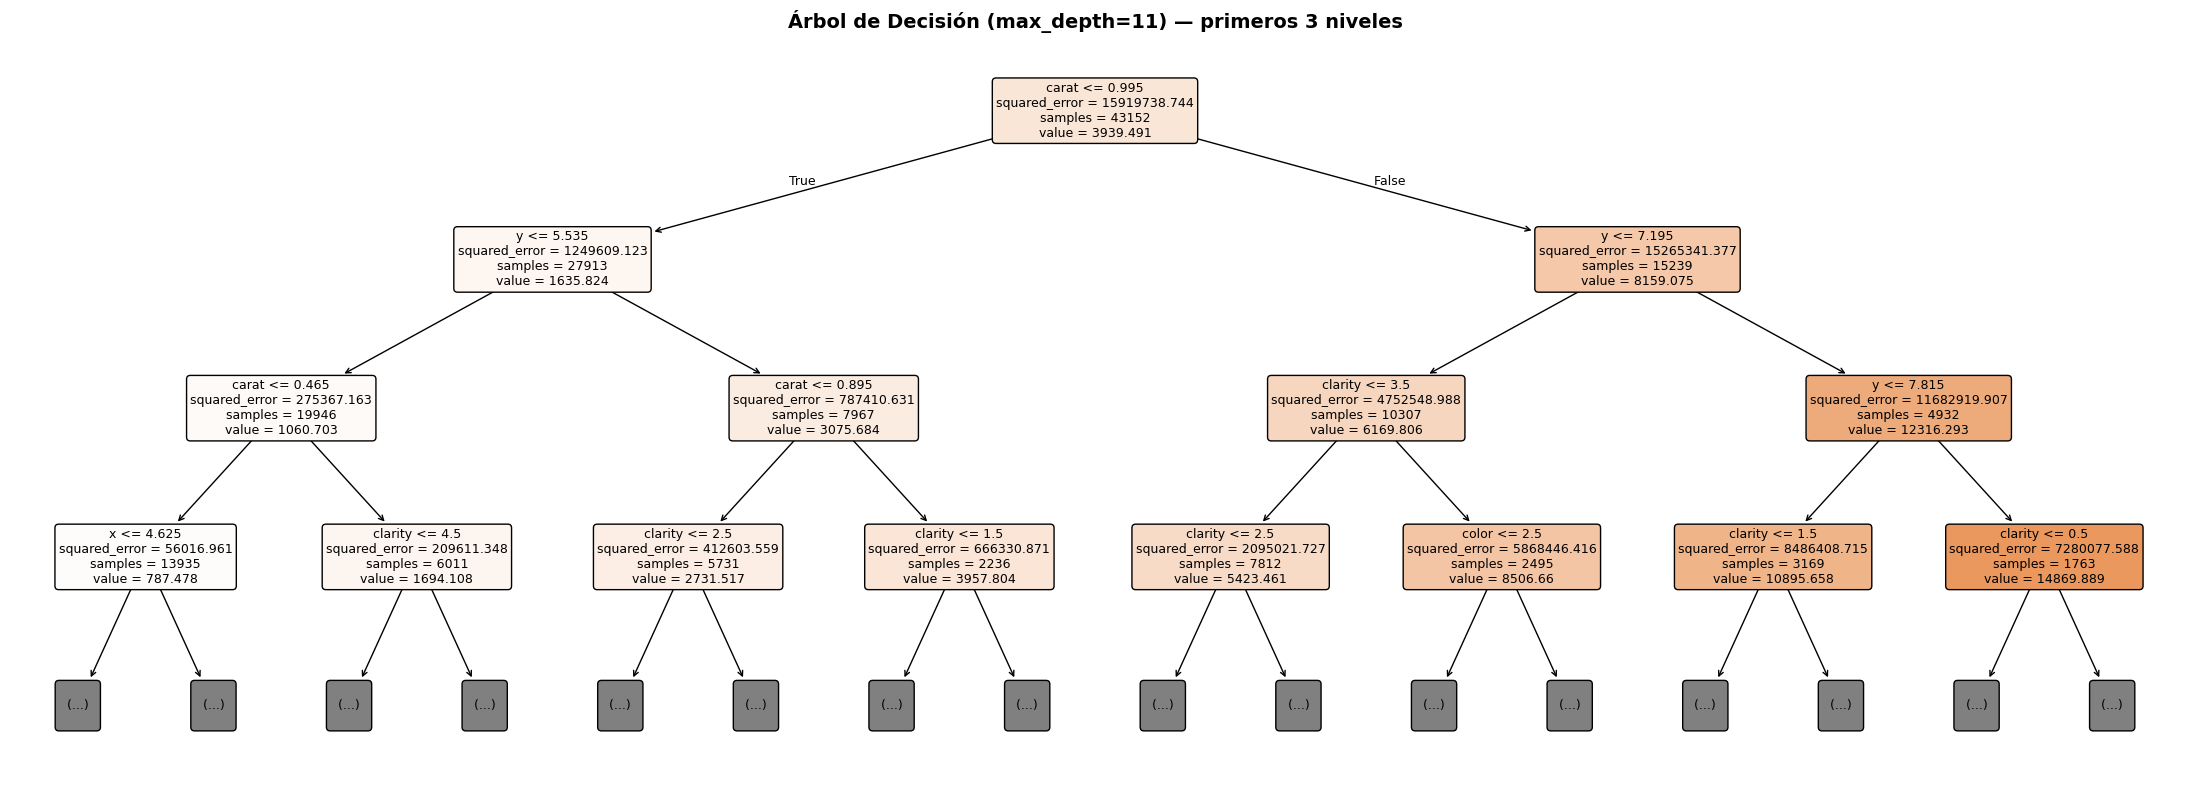

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = list(X_train_enc.columns)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    tree,                          # estimador interno, no el Pipeline
    max_depth=3,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title(f'Árbol de Decisión (max_depth={best_depth}) — primeros 3 niveles',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6️⃣ Importancia de Variables

Los árboles calculan la **importancia de cada variable** midiendo cuánto reduce el MSE en promedio cada vez que esa variable se usa para hacer un corte, ponderado por el número de muestras que pasan por ese nodo.

> A diferencia de los coeficientes OLS, esta importancia es siempre **positiva** y suma 1.  
> No indica dirección (positivo/negativo), solo cuánto contribuye cada variable a reducir el error.


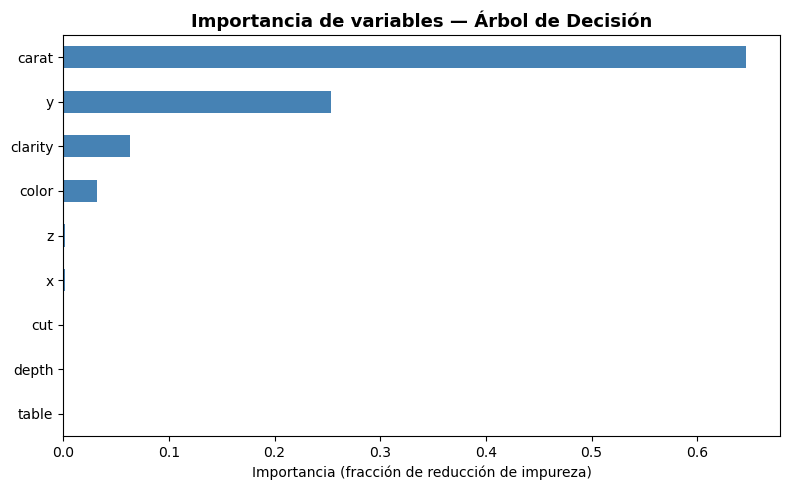

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = list(X_train_enc.columns)
importances = pd.Series(tree.feature_importances_, index=feature_names)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_sorted.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de variables — Árbol de Decisión', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (fracción de reducción de impureza)')
plt.tight_layout()
plt.show()

## 7️⃣ Evaluación en Test

Calculamos R², RMSE y MAPE — las mismas métricas que en OLS y KNN para comparar los tres modelos.


In [10]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from math import sqrt

y_pred_dt = grid.predict(X_test_enc)

r2_dt   = r2_score(y_test, y_pred_dt)
rmse_dt = sqrt(mean_squared_error(y_test, y_pred_dt))
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt) * 100

print(f"R²   en test: {r2_dt:.4f}")
print(f"RMSE en test: {rmse_dt:.2f} USD")
print(f"MAPE en test: {mape_dt:.2f}%")


R²   en test: 0.9756
RMSE en test: 622.71 USD
MAPE en test: 8.84%


## 8️⃣ Real vs Predicho

Los árboles producen predicciones en **escalones** (el promedio de cada hoja), no valores continuos.  
Esto se nota en el gráfico como líneas horizontales de puntos — es comportamiento normal del modelo.


In [11]:
import plotly.express as px

fig = px.scatter(
    x=y_test, y=y_pred_dt,
    labels={'x': 'Precio real (USD)', 'y': 'Precio predicho (USD)'},
    title=f'Árbol de Decisión (max_depth={best_depth}) — Real vs Predicho en Test',
    opacity=0.3,
    template='plotly_white'
)
max_val = max(y_test.max(), y_pred_dt.max())
fig.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val,
              line=dict(color='red', dash='dash'))
fig.show()


NameError: name 'px' is not defined

## 9️⃣ Comparación Final: OLS vs KNN vs Árbol de Decisión

| | OLS | KNN | Árbol de Decisión |
|---|---|---|---|
| **Requiere escalado** | No | ✅ Sí | No |
| **Asume linealidad** | ✅ Sí | No | No |
| **Interpretable** | Coeficientes | ❌ No directo | ✅ Reglas visuales |
| **Importancia variables** | Coef. estandarizados | ❌ No | ✅ Nativa |
| **Riesgo de sobreajuste** | Bajo | Medio | ⚠️ Alto sin `max_depth` |
